In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/siddharth0935/toy-store-e-commerce-database/products.csv
/kaggle/input/datasets/siddharth0935/toy-store-e-commerce-database/order_items.csv
/kaggle/input/datasets/siddharth0935/toy-store-e-commerce-database/order_item_refunds.csv
/kaggle/input/datasets/siddharth0935/toy-store-e-commerce-database/orders.csv
/kaggle/input/datasets/siddharth0935/toy-store-e-commerce-database/website_sessions.csv
/kaggle/input/datasets/siddharth0935/toy-store-e-commerce-database/_fuzzy_factory_data_dictionary.csv
/kaggle/input/datasets/siddharth0935/toy-store-e-commerce-database/website_pageviews.csv


# Strategic Growth Opportunities: A Diagnostic Analysis of Maven Fuzzy Factory’s E-Commerce Performance (2012–2015)

As Maven Fuzzy Factory scales its e-commerce operations, understanding the underlying drivers of revenue and customer behavior becomes critical for sustainable growth. This project presents a diagnostic analysis of the company's transactional data and site traffic from 2012 to 2015, identifying opportunities across revenue performance, customer acquisition, and business strategy.

By examining trends in traffic patterns, conversion rates, and product sales, this analysis identifies three strategic opportunities: bridging the widening gap between weekday and weekend sales, capitalizing on strong conversion rates to expand market reach, and diversifying the product portfolio. The insights derived serve as actionable, data-driven recommendations for maximising revenue growth.

## Objectives
The primary goal of this analysis is to conduct a comprehensive diagnostic review of Maven Fuzzy Factory’s e-commerce performance (2012–2015) to identify actionable strategies for revenue growth and operational efficiency. Specifically, this project aims to:
1. Evaluate Overall Sales Performance & Trends
2. Derive Actionable Strategic Recommendations

### Understanding The Data

This dataset contains 7 tables in total:

| CSV Name | Description | DataFrame Name|
| --- | --- | ---|
| 1. _fuzzy_factory_data_dictionary | Contains variable descriptions for this dataset | None |
| 2. order_item_refunds | Details on product refunds | refunds_df | 
| 3. order_itens | Details on products ordered | order_items_df |
| 4. orders | Details on online orders | orders_df |
| 5. products | Details on products | products_df |
| 6. website_pageviews | Details on page views per session ID | pageviews_df |
| 7. website_sessions | Details on sessions per user ID | sessions_df |



### Data Limitations
This data contains several limitations that limit the accuracy of this analysis:
1. **Limited context to the business page:** This analysis can only provide a quantitative analysis of the advertising campaigns due to the lack of access and context on the URLs provided.
2. **Limited context of user behaviour:** The dataset does not include the website's end-of-session timestamp and the user's database, which limits how we assess user engagement per funnel and how we analyze the profiles of retaining customers.

## Data Preparation and Cleaning

In [2]:
dataframes = []
i = 0
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        dataframe = os.path.join(dirname, filename)
        dataframes.append(dataframe)
        i += 1

products_df = pd.read_csv(dataframes[0])
order_items_df = pd.read_csv(dataframes[1])
refunds_df = pd.read_csv(dataframes[2])
orders_df = pd.read_csv(dataframes[3])
sessions_df = pd.read_csv(dataframes[4])
pageviews_df = pd.read_csv(dataframes[6])

In [3]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB


In [4]:
orders_df.duplicated().value_counts()

False    32313
Name: count, dtype: int64

In [5]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.1+ MB


In [6]:
order_items_df.duplicated().value_counts()

False    40025
Name: count, dtype: int64

In [7]:
sessions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   created_at          472871 non-null  object
 2   user_id             472871 non-null  int64 
 3   is_repeat_session   472871 non-null  int64 
 4   utm_source          389543 non-null  object
 5   utm_campaign        389543 non-null  object
 6   utm_content         389543 non-null  object
 7   device_type         472871 non-null  object
 8   http_referer        432954 non-null  object
dtypes: int64(3), object(6)
memory usage: 32.5+ MB


In [8]:
sessions_df.isna().sum()

website_session_id        0
created_at                0
user_id                   0
is_repeat_session         0
utm_source            83328
utm_campaign          83328
utm_content           83328
device_type               0
http_referer          39917
dtype: int64

Three columns in `sessions_df` have missing data: `utm_source`, `utm_campaign`, and `utm_content`. Despite missing ~20% of the data in these columns, there are several possible explanations for this. Typically, `utm_source` will be missing in the conditions where the website is accessed organically, or when being typed manually by the user. Other cases include browser behaviour, where some browsers may strip the `utm_source` to maintain the user's privacy, or when the user themselves accessed the website in private modes.

The missing data in the `http_referer` requires further investigation, but there is no reason to remove this missing data as they provide valuable insights on organic traffics.

In [9]:
pageviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   website_pageview_id  1188124 non-null  int64 
 1   created_at           1188124 non-null  object
 2   website_session_id   1188124 non-null  int64 
 3   pageview_url         1188124 non-null  object
dtypes: int64(2), object(2)
memory usage: 36.3+ MB


In [10]:
pageviews_df.duplicated().value_counts()

False    1188124
Name: count, dtype: int64

In [11]:
df_list = [pageviews_df, orders_df, order_items_df, sessions_df, products_df, refunds_df]
for df in df_list:
    df['created_at'] = pd.to_datetime(df['created_at'])
    df['date'] = df['created_at'].dt.date
    df['day_of_week'] = df['created_at'].dt.day_name()
    if 'cogs_usd' in list(df.columns):
        df['gross_profit'] = df['price_usd'] - df['cogs_usd']


All dataframes have a `created_at` column that signifies their unique timestamps, which will be valuable for this analysis, and thus are converted into the appropriate datetime object.

---
# Revenue Analysis

To understand the overall business health of Maven Fuzzy Factory, an analysis of how the business is acquiring revenue is conducted. The methodology for this analysis is to plot a line chart of daily end-of-day sales and QoQ growth over the data period. Daily end-of-day sales are chosen as the key metric for this analysis because the granularity will provide a deeper insight into any recurring trends that are absent if aggregated by end-of-week or end-of-month sales. Meanwhile, QoQ is chosen as the growth metric as it is less affected by trend volatility but maintains information on seasonality trends.

In [12]:
sales_df = orders_df.resample('D', on='created_at').agg(
    gross_profit = ('gross_profit', 'sum'),
    sales_count = ('gross_profit', 'count')
).reset_index()

In [13]:
sales_df.head()

,created_at,gross_profit,sales_count
0,2012-03-19,61.0,2
1,2012-03-20,183.0,6
2,2012-03-21,274.5,9
3,2012-03-22,122.0,4
4,2012-03-23,91.5,3


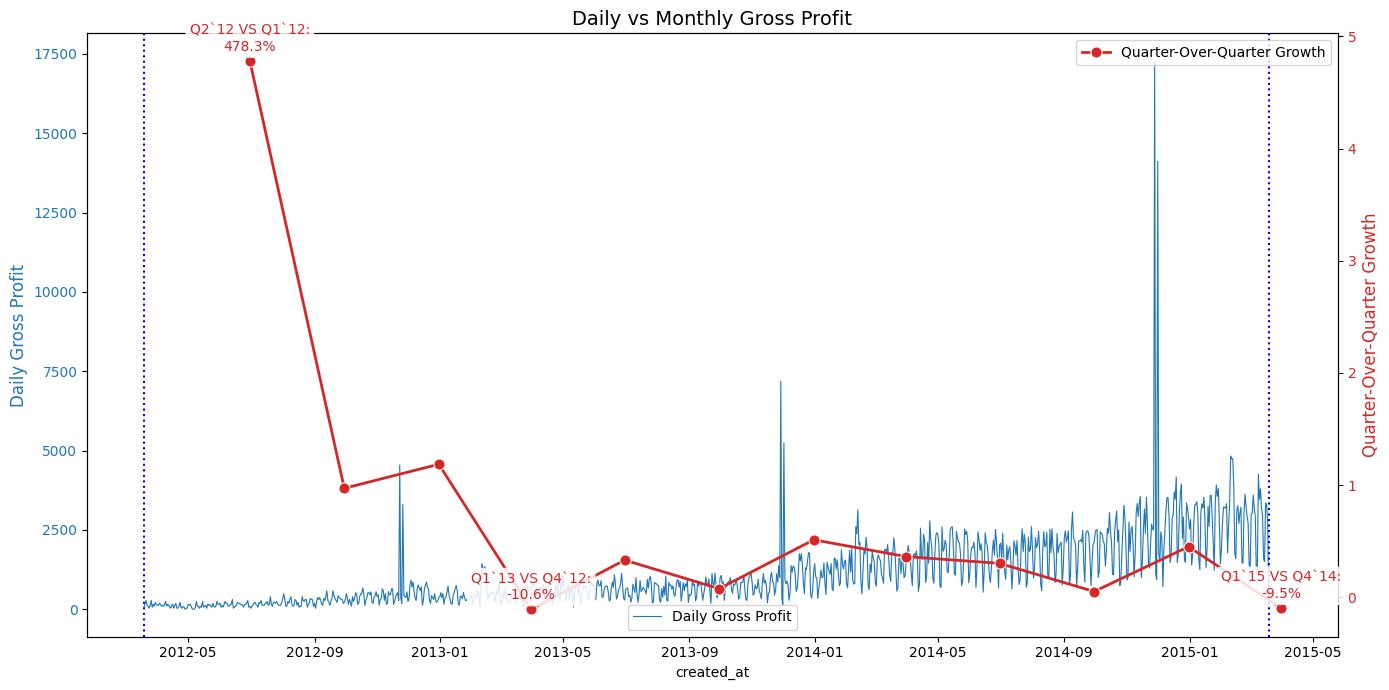

In [14]:
fig, ax1 = plt.subplots(1, 1, figsize=(14, 7))

# --- 1. Daily Plot (Left Axis) ---
# Using the original daily data
sns.lineplot(
    data=sales_df, 
    x='created_at', y='gross_profit',
    estimator='sum', errorbar=None,
    color='#1f77b4', linewidth=0.8, 
    ax=ax1, label='Daily Gross Profit'
)
ax1.set_ylabel('Daily Gross Profit', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_title('Daily vs Monthly Gross Profit', fontsize=14)

# --- 2. Monthly Plot (Right Axis) ---
ax2 = ax1.twinx()

quarterly = sales_df.resample('QE', on='created_at')['gross_profit'].sum().reset_index()
quarterly['quarter_over_quarter'] = (quarterly['gross_profit']/quarterly['gross_profit'].shift(1)) -1

# Plot on secondary axis
sns.lineplot(
    data=quarterly,
    x='created_at', y='quarter_over_quarter',
    color='#d62728', marker='o', markersize=8,
    linewidth=2,
    ax=ax2, label='Quarter-Over-Quarter Growth'
)
ax2.set_ylabel('Quarter-Over-Quarter Growth', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.xticks(rotation=45)

indices_to_label = [1, 4, 12]
for i in indices_to_label:
    if i < len(quarterly):
        row = quarterly.iloc[i]
        row_prior = quarterly.iloc[i-1]
        x_val = row['created_at']
        y_val = row['quarter_over_quarter']
        q_actual = f"Q{row['created_at'].quarter}`{row['created_at'].strftime('%y')}"
        q_prior = f"Q{row_prior['created_at'].quarter}`{row_prior['created_at'].strftime('%y')}"
        date_text = q_actual + ' VS ' + q_prior
        label_text = f"{date_text}:\n{y_val:.1%}"
        offset_y = 5
        ax2.annotate(
            label_text,
            xy=(x_val, y_val),
            xytext=(0, offset_y), 
            textcoords="offset points",
            fontsize=10,
            color='#d62728',
            ha='center',
            va='bottom',bbox=dict(
                boxstyle="round,pad=0.3", 
                facecolor="white", 
                alpha=0.85, 
                edgecolor="none"
            ),
            arrowprops=dict(arrowstyle='-', color='#d62728', lw=1)
        )

ax1.axvline(x=sales_df['created_at'].min(),
            color='blue', linestyle=':',
           label='Last Recorded Date')
ax1.axvline(x=sales_df['created_at'].max(),
            color='blue', linestyle=':',
            label='Last Recorded Date')

plt.tight_layout()
plt.show()

## Daily Gross Profit and QoQ Growth

The line chart above shows the daily gross profit from March 19th, 2012, until March 19th, 2015, and the QoQ growth across the 3-year period.

Since 2012, the gross profit from toy sales has shown strong growth each year, with YoY growth close to 200% each year. However, the daily gross profit chart shows volatility in daily sales, with frequent drops in gross profit and seasonal peaks in Q4 each year.

**QoQ Analysis**
1. **Q1'12 vs Q2'12:** Despite the high QoQ growth of up to 480%, this figure is driven by the immature sales quarter of Q1, as the earliest sales are recorded on mid-March 2012. QoQ for gross profit peaks as we compare a partial quarter against a full quarter.
2. **Q1'13 vs Q4'12:** A dip in QoQ (-10.6%) is caused by our first wave of seasonal purchases in Q4 2012. A spike in gross profit near the end of 2012 and the immediate return to baseline causes a decline, but does not raise a red flag.
3. **Q1'14 vs Q1'13:** Q1 of 2014 seems to show a decent QoQ growth despite the seasonal purchases in Q4 2013. Sales increased from the previous baseline from 2014 onwards, with decent growth in each quarter.
4. **Q1'15 vs Q4'14:** Note that Q1 2015 is also an incomplete sales record, with the last sale dated on 19th March, almost 2 weeks away from a full quarter. A -9.5% QoQ requires adjustments to account for the cutoff for a fairer representation of the dataset.

The overall QoQ shows a healthy, growing business with the ability to maintain a competitive gross profit relative to its baseline. However, daily gross profit seems to show a volatile pattern with sharp declines at intervals. Understanding these sales fluctuations will provide an actionable insight into how to maximize growth.

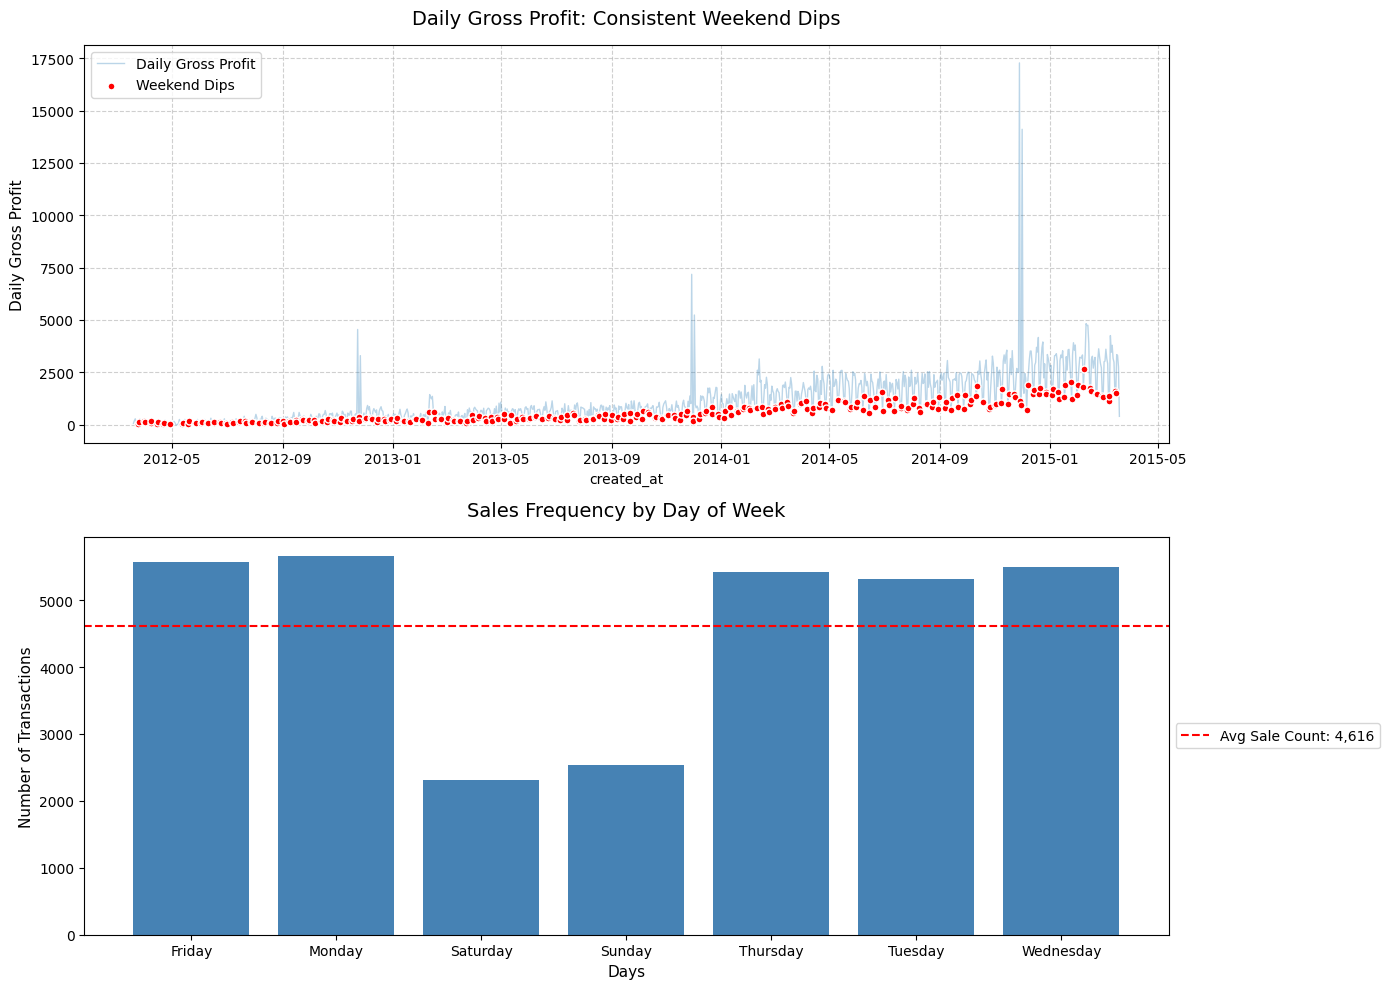

In [15]:
# Create a figure with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1]})

# --- Plot 1: Time Series (Daily Gross Profit) ---
# We use the ax1 object instead of 'ax'
sns.lineplot(
    x=sales_df['created_at'], y=sales_df['gross_profit'],
    estimator='sum', errorbar=None,
    color='#1f77b4', alpha=0.3, linewidth=1,
    ax=ax1, label='Daily Gross Profit'
)

# Highlight Weekend Points on ax1
sales_df['is_weekend'] = sales_df['created_at'].dt.dayofweek >= 5
weekend_data = sales_df[sales_df['is_weekend']].resample('D', on='created_at')['gross_profit'].sum().reset_index()
weekend_data = weekend_data.replace(0, np.nan).dropna()

sns.scatterplot(
    x=weekend_data['created_at'], y=weekend_data['gross_profit'], 
    color='red', s=25, zorder=5,
    label='Weekend Dips', edgecolors='white', linewidth=1,
    ax=ax1
)

ax1.set_title('Daily Gross Profit: Consistent Weekend Dips', fontsize=14, pad=15)
ax1.set_ylabel('Daily Gross Profit', fontsize=11)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)


# --- Plot 2: Bar Chart (Sales Frequency by Day) ---
sales_df['day_of_week'] = sales_df['created_at'].dt.day_name()
freq_data = sales_df.groupby('day_of_week')['sales_count'].sum().reset_index()

# Reorder categories for Monday-Friday-Sunday logic if needed, 
# but default alphabetical is fine for now unless you want Mon-Sun order
# freq_data = freq_data.reindex(['Monday', 'Tuesday', ...]) 

bars = ax2.bar(freq_data['day_of_week'], freq_data['sales_count'], color='steelblue')
mean_count = freq_data['sales_count'].mean()

ax2.axhline(mean_count, color='red', linestyle='--', linewidth=1.5, label=f'Avg Sale Count: {mean_count:,.0f}')

ax2.set_title('Sales Frequency by Day of Week', fontsize=14, pad=15)
ax2.set_ylabel('Number of Transactions', fontsize=11)
ax2.set_xlabel('Days', fontsize=11)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Weekend Traffic Dips

The line chart represents the daily gross profit generated over time, with red dots highlighting weekend sales. The volatility and low daily sales are explained by the above graph. Weekend sales show noticeably low gross profit, implying strong correlations between low sales and weekends. The bar chart shows how wide the gap is between weekend and weekday sales, as the total number of sales within 3 years is half the record average sales by day of week.

This implies that the main driver for this pattern is the significantly lower number of sales on weekends compared to weekdays. Understanding the factors behind low sales on weekends will help us take actionable steps to increase overall gross profit by maximizing daily sales. To understand the reasons behind low sales on weekends, we must explore the weekend vs weekday website traffic. If there are similar web session counts, this pattern is signalling different customer behaviours. Insights from this analysis will also allow us to strategize better campaign strategies for weekends.

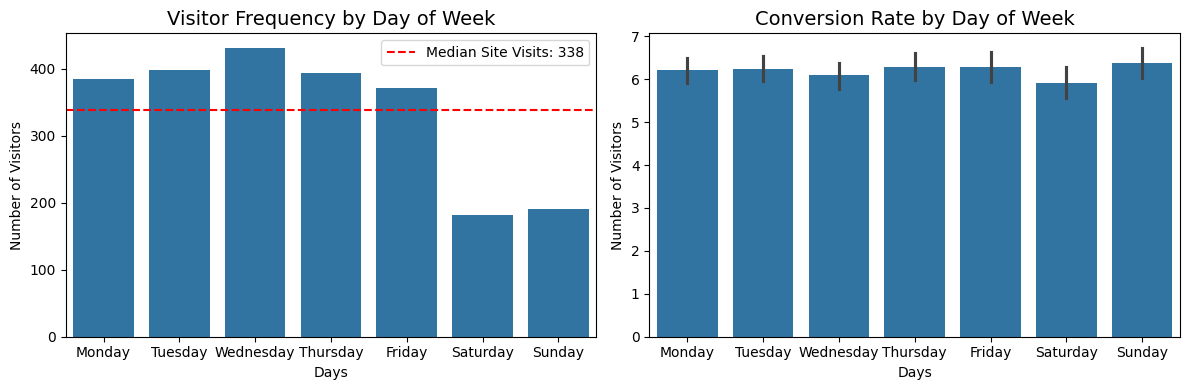

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

freq_data = sessions_df.resample('D', on='created_at')['website_session_id'].size().reset_index()
freq_data['day_name'] = freq_data['created_at'].dt.day_name()

sns.barplot(
    freq_data,
    x='day_name', y='website_session_id',
    estimator=np.median, errorbar=None,
    ax=ax1
)

mean_count = freq_data['website_session_id'].median()
ax1.axhline(mean_count, color='red', linestyle='--', linewidth=1.5, label=f'Median Site Visits: {mean_count:,.0f}')

ax1.set_title('Visitor Frequency by Day of Week', fontsize=14)
ax1.set_ylabel('Number of Visitors')
ax1.set_xlabel('Days')
ax1.legend(loc='upper right')

converted_sessions = list(orders_df['website_session_id'])
converted = sessions_df[sessions_df['website_session_id'].isin(
    converted_sessions
)].resample(
    'D', on='created_at'
)['website_session_id'].size().reset_index()
converted['day_name'] = converted['created_at'].dt.day_name()

total = sessions_df.resample('D', on='created_at')['website_session_id'].size().reset_index(drop=True)
converted['cvr'] = (converted['website_session_id'] / total) * 100

sns.barplot(
    converted,
    x='day_name', y='cvr',
    ax=ax2
)


ax2.set_title('Conversion Rate by Day of Week', fontsize=14)
ax2.set_ylabel('Number of Visitors')
ax2.set_xlabel('Days')

plt.tight_layout()
plt.show()

Weekend sessions consistently underperform weekday sessions in traffic volume, with fewer website visits, and the gap is widening over time despite steady growth across all days. Critically, conversion rates remain equal across all days of the week — meaning weekend visitors are equally valuable per session, but there are simply fewer of them arriving. The underperformance is device-agnostic and campaign-agnostic, suggesting this is a demand-side behavioral pattern rather than an acquisition mix problem. This represents a quantifiable, recoverable revenue opportunity: closing even a fraction of the weekday-weekend traffic gap at the existing conversion rate translates directly to proportional revenue gains. 

$$\text{Average Weekend-Weekday Gap for 2014 and beyond} = \$1,311$$

| Weekend Visitor Increase | Additional Monthly Profit Projection | Yearly Opportunity |
|---|---|---|
|10%|\$1,135|\$13,624|
|25%|\$2,838|\$34,060|
|50%|\$5,677|\$68,120|

The projected numbers are based on the most recent gap. The current trend shows a widening gap between weekend and weekday sales performance, which means more to lose in the upcoming years. Future business strategies must target weekends to bring visitors closer to the median line, maximising profit. Tactics could include weekend-specific promotions or email marketing campaigns and adjusting ad spend to target weekend browsing habits.

In [17]:
peak_date = []

for year in list(sales_df['created_at'].dt.year.unique()):
    df = sales_df[sales_df['created_at'].dt.year == year]
    # df = sales_df[mask]
    max_sale = df['sales_count'].max()
    peak_date.extend(
        date for date in df.loc[df['sales_count'] == max_sale, 'created_at'].dt.strftime('%Y-%m-%d')
    )

peak_date

# max_sale = sales_df['sales_count'].max()
# sales_df.loc[sales_df['sales_count'] == max_sale, 'created_at'].values

['2012-11-23', '2013-11-29', '2014-11-28', '2015-02-10', '2015-02-11']

In [18]:
sales_df.head()

,created_at,gross_profit,sales_count,is_weekend,day_of_week
0,2012-03-19,61.0,2,False,Monday
1,2012-03-20,183.0,6,False,Tuesday
2,2012-03-21,274.5,9,False,Wednesday
3,2012-03-22,122.0,4,False,Thursday
4,2012-03-23,91.5,3,False,Friday


---
# Conversion Analysis

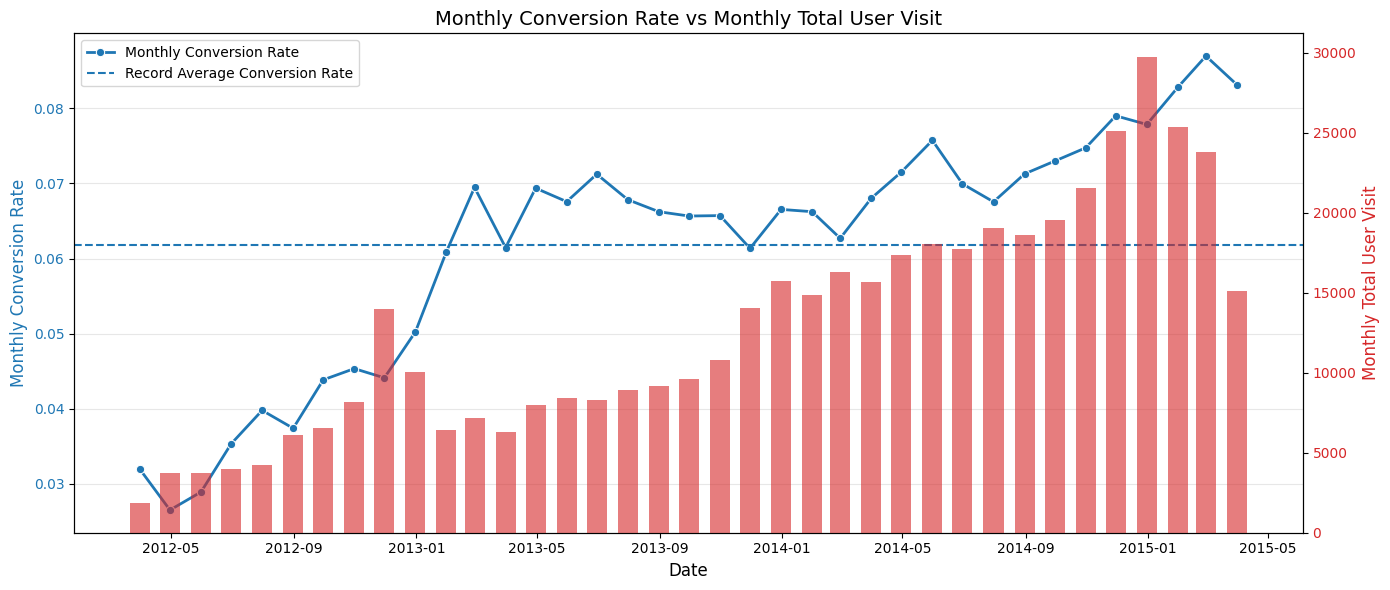

date
2012    0.038334
2013    0.066113
2014    0.071461
2015    0.084301
Name: cvr, dtype: float64


In [19]:
monthly_conversion = pageviews_df.resample(
    'ME', on='created_at'
)['website_session_id'].nunique().reset_index().join(
    orders_df.resample('ME', on='created_at')['website_session_id'].nunique(), on='created_at',
    rsuffix='_converted'
)

monthly_conversion['cvr'] = monthly_conversion['website_session_id_converted'] / monthly_conversion['website_session_id']
monthly_conversion.columns = ['date', 'total_visits', 'converted', 'cvr']

# --- 3. Create Dual-Axis Plot ---
fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))

# Left axis: Conversion Rate (line plot)
sns.lineplot(
    data=monthly_conversion,
    x='date', y='cvr',
    color='#1f77b4', linewidth=2,
    ax=ax1, label='Monthly Conversion Rate', marker='o'
)
ax1.set_ylabel('Monthly Conversion Rate', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_title('Monthly Conversion Rate vs Monthly Total User Visit', fontsize=14)
ax1.axhline(y=monthly_conversion['cvr'].mean(), color='#1f77b4', linestyle='--', label='Record Average Conversion Rate')
ax1.legend(loc='upper left')

# Right axis: Total Visits (bar plot)
ax2 = ax1.twinx()
ax2.bar(
    monthly_conversion['date'],
    monthly_conversion['total_visits'],
    color='#d62728', alpha=0.6, width=20,
    label='Monthly Total User Visits'
)
ax2.set_ylabel('Monthly Total User Visit', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

# Format x-axis
plt.xticks(rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(monthly_conversion.groupby(
    monthly_conversion['date'].dt.year
)['cvr'].mean())

The chart shows the Monthly Conversion Rate and the Monthly Total Website Visitors. The bar represents the sum of website visitors by month, and the line represents the conversion rate of the month. 

As established in prior sections, the gross profit and site visitors throughout the dataset have seen a steady climb from 2012 to 2015. On top of that, this visual reveals that the monthly conversion rate is also steadily increasing, with a steep climb from 2013 onwards. Beyond Q2 2013, the monthly conversion rate settles above the record average conversion rate of ~6%, occasionally touching 7%. The conversion rate rises and peaks in February 2015 at ~9%. This steady increase is reflected in the average yearly conversion rate.

This pattern shows that Maven Fuzzy Factory has had a steadily growing customer base over the years. Despite the sales dipping in Q1 every year as seasonality dies down, the conversion rate seems to be unaffected. We can capitalize on this trend by riding out the high conversion rates after the year-end seasonality spike with aggressive marketing campaigns focusing on New Year discounts.

The conversion rates show little volatility across the record. We can also take this as a sign of brand establishment and market trust; therefore, releasing a new product line will have a massive ROI potential.

---
# Funnel Analysis

A customer journey is the complete sequence of interactions and experiences a person has with a brand, encompassing all touchpoints from initial discovery through post-purchase advocacy.  Unlike the buyer’s journey, which ends at the transaction, the customer journey includes ongoing engagement and retention phases, recognizing that the process is often non-linear with potential feedback loops.

The code cell below creates a new column named `journey_map` that maps the users' interaction pages by the pages they viewed. This classification is important as there are multiple `pageview_url`s that correspond to the same interaction stage; there are 6 landing pages, 4 product pages, and 2 billing pages.

In [20]:
### Customer Journey 
# Mapping each page URL with its respective interaction sequence

landing_pages = ['/home','/lander-1','/lander-2','/lander-3','/lander-4','/lander-5']

evaluation_pages = ['/products']

products_pages = ['/the-original-mr-fuzzy','/the-forever-love-bear',
    '/the-birthday-sugar-panda','/the-hudson-river-mini-bear']

cart_pages = ['/cart']

shipping_pages = ['/shipping']

billing_pages = ['/billing','/billing-2']

conversion_pages = ['/thank-you-for-your-order']

funnel = {
    'landing_pages':landing_pages,
    'evaluation_pages': evaluation_pages,
    'products_pages':products_pages,
    'cart_pages':cart_pages,
    'shipping_pages': shipping_pages,
    'billing_pages':billing_pages,
    'conversion_pages':conversion_pages
}

for name, stages in funnel.items():
    pageviews_df.loc[pageviews_df['pageview_url'].isin(stages), ['journey_map']] = name

In [21]:
### Preparing Sankey Diagram data
# This code is used to calculate the vector values for a Sankey diagram in the next cell

stage_list = list(funnel.keys())
sankey_data = []

for i in range(len(stage_list)):
    current_stage = stage_list[i]
    previous_stage = stage_list[i - 1] if i - 1 >= 0 else None
    
    mask = pageviews_df['journey_map'] == current_stage
    mask2 = pageviews_df['journey_map'] == previous_stage

    # if previous_stage:
    vector = (pageviews_df[mask|mask2]
              .groupby('website_session_id')['pageview_url']
              .sum()
              .value_counts()
              .to_dict())
   
    sankey_data.append(vector)

In [22]:
#Verifying if any website_session_id referred to the same pageview_url more than once
pageviews_df[['website_session_id', 'pageview_url']].duplicated().value_counts()

False    1188124
Name: count, dtype: int64

In [23]:
#Verifying if any website_session_id referred to the same journey_map more than once
pageviews_df[['website_session_id', 'journey_map']].duplicated().value_counts()

False    1188124
Name: count, dtype: int64

### Verifying duplicate sessions

There may be occurrences where a user goes back and forth between stages or pageviews. The two cells above checked for duplicates of `website_session_id` and `pageview_url` or `journey_map` to ensure the interactions are linear. The output cells showed that all `website_session_id` and `pageview_url`s or `journey_map`s are unique

In [24]:
plot_data = {
    pair: values 
    for vectors in sankey_data
    for pair, values in vectors.items()
    if pair not in [el for lists in funnel.values() for el in lists]
}

label_list = ['entry'] + [el for lists in funnel.values() for el in lists]

total = pageviews_df[pageviews_df['journey_map'] == 'landing_pages']
entry_count = total['pageview_url'].value_counts().to_list()

source = [0]*6 + [1,3,6,4,2,5] + [7]*4 + [8,9,10,11] + [12] + [13]*2 + [15,14]
target = [1,3,6,4,2,5] + [7]*6 + [8,9,10,11] + [12]*4 + [13] + [15,14] + [16, 16]
count = entry_count + list(plot_data.values())

print(f"Label count: {(count)}")


fig = go.Figure(data=[go.Sankey(
    node = {"label": label_list,
           'pad': 15, 'thickness': 15, 'line': {'color': 'black', 'width': 0.5}},
    link = {"source": source, "target": target, "value": count}
    )])
    
fig.show()

Label count: [137576, 131170, 79000, 68166, 47574, 9385, 80230, 71921, 43035, 39267, 22244, 4534, 162525, 26033, 19046, 2610, 69957, 14485, 8811, 1700, 64484, 48441, 3617, 30693, 1620]


## Sankey Diagram

**Note:** In the case of the Sankey diagram not loading in the notebook, please refer to this link.

The Sankey Diagram above visualizes the user navigation flow through the website, starting from the landing pages all the way to the conversion page. The width of each node signifies the total number of users who reached the interaction stage, and the links represent the number of users who proceeded to the next stage(s). The `entry` node visualizes the total visitors who started an interaction with the website.

There are a few key insights from this visual;

* **High Drop-Off in Landing Pages:** The Sankey diagram shows that almost half of the users stopped their interaction in the landing pages and did not proceed to `/products` page, as observed by the thickness of the link from `entry` to landing pages and landing pages to `/products`.
* **High Drop-Off in `/the-original-mr-fuzzy`:** Users reached this specific product selection and do not proceed to `/cart` page.
* **Node Size Differences:** Nodes for each interaction stage show different sizes, signifying that some pages in the same interaction stage receive different traffic sizes throughout the data.

While high drop-off rates can be alarming, they are a fundamental characteristic of e-commerce user behavior. Not every visitor arrives with immediate purchase intent; many are in the discovery or research phase. This is often due to price comparison, lack of immediate need, or simply exploring options without a commitment.

A critical insight that should not be overlooked is the high drop-off in `/the-original-mr-fuzzy` node compared to adjacent nodes. While this product has generated the biggest revenue for this business, it introduced a conversion bottleneck that causes;
* **Direct Sales Loss** as customers did not complete the purchase of this product
* **Cross Product Opportunity Loss** as this product is inadvertently blocking conversion opportunities for other items in the catalog that these users might have purchased had they been presented with a viable alternative earlier in the flow.

In other words, there is a chance that `/the-original-mr-fuzzy` is generating a lot of revenue by 'swallowing' other products. Investigating why this product is pulling so much traffic compared to other products will help in forming a better `/products` page in future website development.

In [25]:
session_summary = pageviews_df.groupby('website_session_id')['journey_map'].agg(['first', 'last'])

started_discovery = session_summary[session_summary['first'] == 'landing_pages']
converted = started_discovery['last'] == 'conversion_pages'

conversion_rate = converted.sum() / len(started_discovery)

exit_distribution = pd.DataFrame({
    'count': started_discovery['last'].value_counts(),
    'proportion': started_discovery['last'].value_counts(normalize=True).round(2)
}).reindex(list(funnel.keys()))

fig = go.Figure(go.Funnel(
    x=pageviews_df['journey_map'].value_counts().to_list(),
    y=list(funnel.keys()),
    textposition = "inside",
    textinfo = "value+percent previous" 
))
# fig.update_traces(
#     texttemplate = '%{value:,}'
# )
fig.show(config={'staticPlot': True})


print("Where did discovery sessions end?")
print(exit_distribution['proportion'])

Where did discovery sessions end?
last
landing_pages       0.45
evaluation_pages    0.11
products_pages      0.24
cart_pages          0.06
shipping_pages      0.03
billing_pages       0.04
conversion_pages    0.07
Name: proportion, dtype: float64


## Drop-Off Funnel

While the Sankey Diagram was able to showcase the overall flow, a funnel diagram will help us quantify the drop-off rate and see the conversion rate at the end. Each node represents an interaction stage with a quantified size and percentages of the current node over the previous node. A table showing the percentages of sessions ending in each stage from the total is also shown.

Key insights:
* **45% Drop-Off from `landing_pages` to `evaluation_pages`** quantifies our Sankey diagram findings of high drop-off in the `landing_pages` stage.
* **55% Drop-Off from `products_page` to `cart_pages`** aligns with our findings in the Sankey diagram.
* **7% Conversion Rate** shown in the table.

The data clearly identifies the Products Page to Cart Page transition as the biggest bottleneck. While fixing the landing page drop-off would bring more users into the middle of the funnel, the immediate highest ROI opportunity lies in optimizing the product display pages to encourage adding items to the cart.

---
# Campaign Analysis

In [26]:
campaigns = sessions_df[['utm_source', 'utm_campaign', 'utm_content']].drop_duplicates().reset_index(drop=True)
campaigns.iloc[1,-1] = 'organic'

sessions_df.fillna({'utm_campaign':'unknown'}, inplace=True)
campaigns

,utm_source,utm_campaign,utm_content
0,gsearch,nonbrand,g_ad_1
1,NaN,NaN,organic
2,gsearch,brand,g_ad_2
3,bsearch,brand,b_ad_2
4,bsearch,nonbrand,b_ad_1
5,socialbook,pilot,social_ad_1
6,socialbook,desktop_targeted,social_ad_2


UTM, or Urchin Tracking Module, is one of the URL parameters used in analytics to track online marketing campaigns across traffic sources and publishing media. There are 6 `utm_campaigns`, tailored to `gsearch`, `bsearch` and `socialbook`. The `NaN` values represent more or less a black box where we cannot accurately identify the source, but are important for this analysis nonetheless. This value is likely to represent:
* **Direct traffic:** Direct traffic represents visitors who already know the brand. They didn't find the website through a search engine or a social media post, but directly via the link.
* **Organic traffic:** Organic traffic is users who found the site naturally in the search results and clicked through.

However, cases such as different browser behaviour and/or edge cases where the UTM content is stripped are also likely. Therefore, `unknown` is assigned to the `NaN` value.

In [27]:
### UTM visit's YOY
# Calculated the YoY growth of customer acquisition by channel

utm_pull = sessions_df.resample('YE', on='created_at')['utm_content'].value_counts(dropna=False).unstack(fill_value=0).reset_index()
prev_year_visit = utm_pull.set_index('created_at').shift(axis=0, periods=1)
utm_yoy_visit = (utm_pull.set_index('created_at')/ prev_year_visit) - 1
utm_yoy_visit = utm_yoy_visit.replace([float('inf'), float('-inf')], None)
utm_yoy_visit = utm_yoy_visit.map(lambda x: f"{x:.1%}" if pd.notnull(x) else "N/A")

### Campaign Time-Series Weekly Data
# Used for stacked area plot in the next cell

campaign_data = sessions_df.resample('W', on='created_at')['utm_content'].value_counts(dropna=False).unstack(fill_value=0).reset_index()
campaign_data.rename(columns={campaign_data.columns[-1]: 'organic'}, inplace=True)

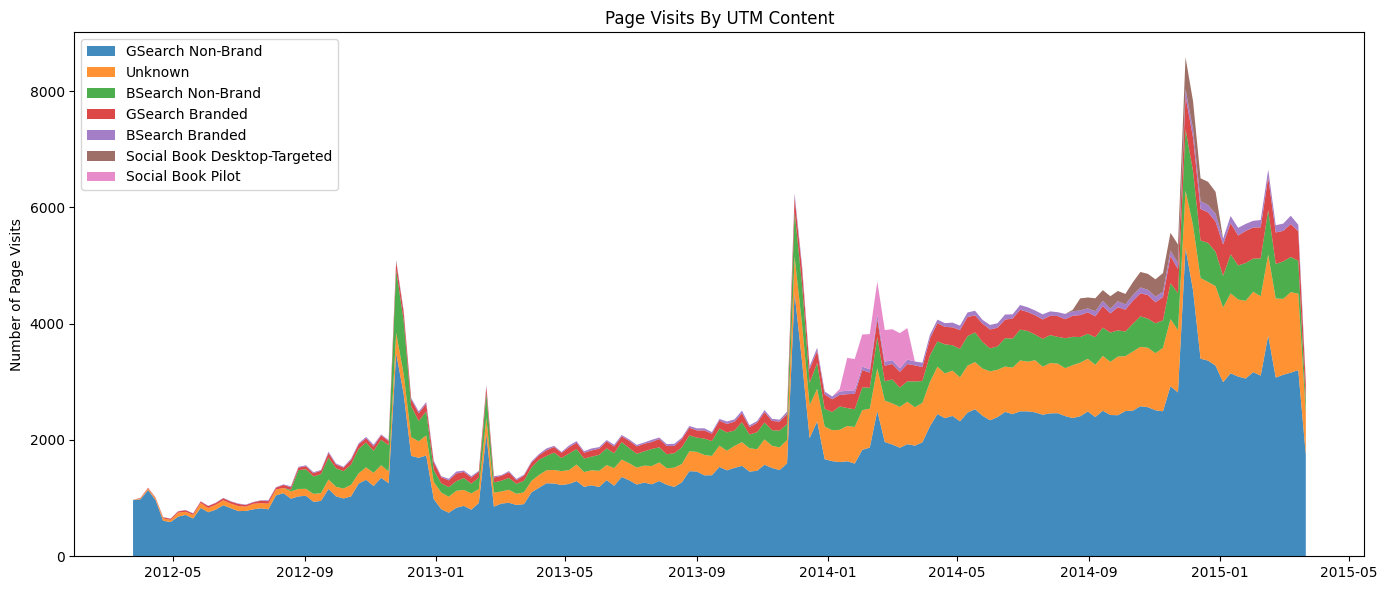

utm_content  b_ad_1  b_ad_2  g_ad_1  g_ad_2  social_ad_1  social_ad_2    NaN
created_at                                                                  
2012-12-31     8269     560   45604    2284            0            0   5753
2013-12-31    14436    1623   72806    6866            0            0  17050
2014-12-31    25367    4362  129154   18245         5095         5590  45609
2015-12-31     6837    1369   35142    5934            0            0  14916


In [28]:
col_sums = campaign_data.drop(columns=['created_at']).sum()
sorted_cols = col_sums.sort_values(ascending=False).index.to_list()

labels=['BSearch Non-Brand', 'BSearch Branded', 'GSearch Non-Brand', 'GSearch Branded',
        'Unknown', 'Social Book Pilot', 'Social Book Desktop-Targeted']

label_map = {campaign: label for campaign, label in zip(
    campaigns.sort_values(by='utm_content')['utm_content'].to_list(),
    labels
)}

sorted_labels = [label_map[col] for col in sorted_cols]

fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))

plot_args = [campaign_data['created_at']] + [campaign_data[col] for col in sorted_cols]

ax1.stackplot(
    *plot_args,
    labels=sorted_labels,
    alpha=0.85
)

ax1.set_title('Page Visits By UTM Content')
ax1.set_ylabel('Number of Page Visits')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(utm_pull.set_index('created_at'))

The stacked area chart shows stacked colored areas representing the density of weekly visitors per acquisition channel from 2012 to 2015, accompanied by a DataFrame table that shows the total number of visitors each year.

Based on the stacked area chart, most of the acquisition channels move in lockstep, with variations in 2012. The biggest acquisition channel is the `g_ad_1` campaign from the non-branded gsearch and accounts for more than half of visitors to the e-commerce page over the 3 years.
Despite the lockstep trend, the growth rates of the channels differ from one another. Other than the growth of the `g_ad_1` campaign, the `unknown` channel shows significant growth compared to other channels, accounting for a quarter of the visitors nearing the end of Q1 2015.

In Q1 2014, `social_ad_1` was introduced as a pilot campaign for expanding the acquisition channels, and in Q4 of the same year, `social_ad_2` was introduced to target desktop users on the Social Book platform. Both of these acquisition channels have shown great market potential as they managed to gain >5000 visitors despite being active for only one quarter.

The data points to a few things:
* **Reliable Market Demand:** All acquisition channels show significant growth throughout the years despite the lockstep, showing potential to attract customers in the long run.
* **Channel Expansion as the Next Step:** The pilot campaign for Social Book has improved traffic by almost 10% in Q1 2014. This is evidence that investing in channel expansion can improve traffic and expand our customer base. The e-commerce landscape has fundamentally shifted toward online marketplaces and social media-driven commerce platforms since 2015, and thus a large untapped potential for increasing traffic.

---
# Product Analysis

In [29]:
details = order_items_df[['product_id', 'price_usd', 'cogs_usd', 'gross_profit']].drop_duplicates().set_index('product_id')

products_df['price_usd'] = products_df['product_id'].map(details['price_usd'])
products_df['cogs_usd'] = products_df['product_id'].map(details['cogs_usd'])
products_df['profit'] = products_df['product_id'].map(details['gross_profit'])
products_df['profit_margin'] = products_df['profit'] / products_df['price_usd']
products_df['markup'] = products_df['profit'] / products_df['cogs_usd']
products_df

,product_id,created_at,product_name,date,day_of_week,price_usd,cogs_usd,profit,profit_margin,markup
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy,2012-03-19,Monday,49.99,19.49,30.5,0.610122,1.564905
1,2,2013-01-06 13:00:00,The Forever Love Bear,2013-01-06,Sunday,59.99,22.49,37.5,0.625104,1.667408
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda,2013-12-12,Thursday,45.99,14.49,31.5,0.684932,2.173913
3,4,2014-02-05 10:00:00,The Hudson River Mini bear,2014-02-05,Wednesday,29.99,9.49,20.5,0.683561,2.160169


There are 4 products sold by the Maven Fuzzy Factory as of 2015. The profit margin for each product ranges between 60% and 70%, and >150% markup (up to 217%). Note that these prices and cost of goods remain static throughout the dataset, and no changes were found. This stability suggests a robust supply chain with predictable unit costs.

Given the high margins and growing traffic, implementing promotional price drops is a viable and sustainable business strategy. This strategy could:

* Leverage existing seasonality peaks.
* Create new demand cycles.
* Drive higher purchase volumes without significantly risking profitability due to the large margin buffer.

### Discount Opportunity Estimation

Since the dataset has no occurrence of a price change, we cannot reliably predict how discounts may affect conversion rates. However, a reasonable assumption would be:
* **Small discounts (5–10%):** ~5–15% conversion uplift
* **Moderate discounts (15–25%):** ~20–40% conversion uplift
* **Aggressive discounts (30%+):** ~40–60%+ uplift

If we use this assumption for `The Original Mr Fuzzy`'s profit and a 6% conversion rate for every 1000 customers as baseline against the min and max of our assumed conversion uplifts per discount band;

| Discount (%) | Purchased | Profit |
| --- | --- | --- |
| 0 | 60 | \$1830 |
| 5 | 63 (+5%) | \$1825 (-1%) |
| 5 | 69 (+15%) | \$1999 (+9%)|
| 15 | 72(+20%) | \$1866 (+2%)|
| 15 | 84(+40%) | \$2177 (+20%)|
| 30 | 90(+50%) | \$1921 (+5%)|


Based on these assumptions, even a low discount of 5% has the potential to generate 9% additional revenue, despite the 1% revenue loss as the worst-case scenario. Discounting item prices during seasonal cycles has the potential for Maven Fuzzy Factory to generate more revenue if strategies are in tandem with good marketing efforts.

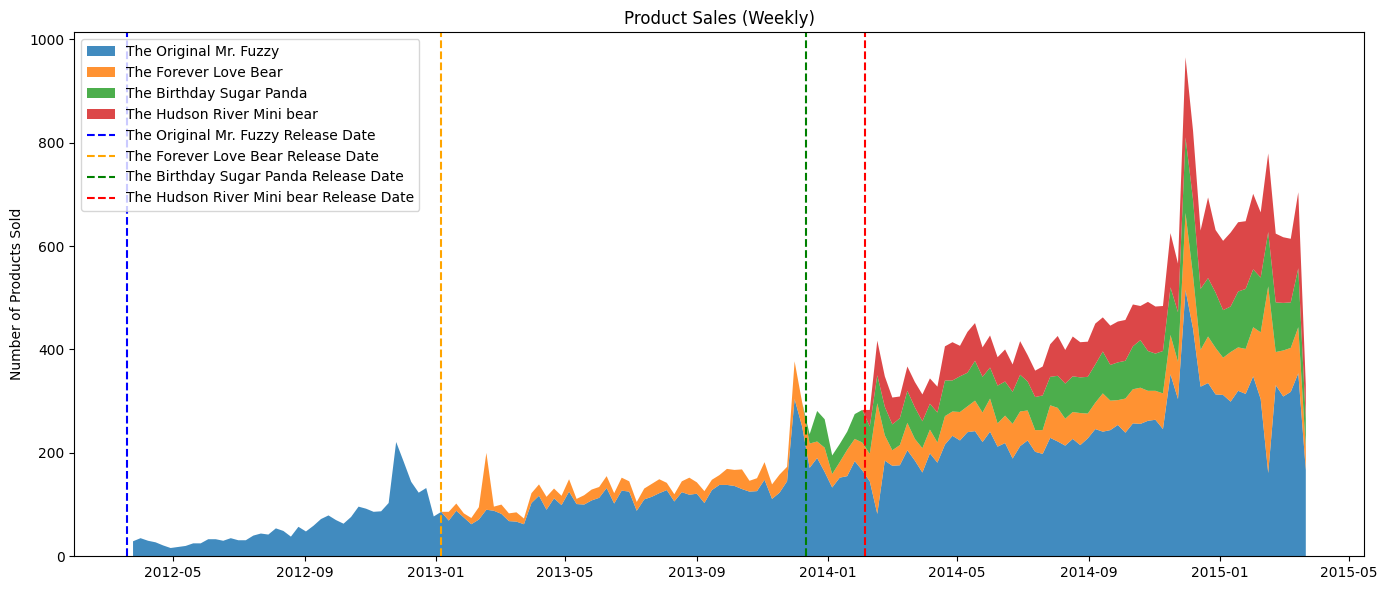

Product Overall Value
created_at     2012      2013      2014      2015     total
product_id                                                 
1           78873.0  187605.5  369660.0  102754.5  738893.0
2               0.0   49612.5  120450.0   47287.5  217350.0
3               0.0    4378.5  117432.0   35217.0  157027.5
4               0.0       0.0   72180.5   30688.5  102869.0


In [30]:
product_sales = order_items_df.resample('W', on='created_at')['product_id'].value_counts().unstack(fill_value=0).reset_index()

fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))

plot_args = [product_sales[col] for col in product_sales.columns.to_list()]

labels = products_df['product_name'].to_list()

ax1.stackplot(
    *plot_args,
    alpha=0.85,
    labels=labels
)
colors = ['b', 'orange', 'g', 'r']

dict_labels = dict(zip(colors, labels))
for color, label in dict_labels.items():
    mask = products_df['product_name'] == label
    ax1.axvline(products_df[mask]['date'].min(), color=color, linestyle='--', label=f'{label} Release Date')

ax1.set_title('Product Sales (Weekly)')
ax1.set_ylabel('Number of Products Sold')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

product_value = order_items_df.groupby(['product_id', order_items_df['created_at'].dt.year])['gross_profit'].sum().unstack(fill_value=0)
product_value['total'] = order_items_df.groupby('product_id')['gross_profit'].sum()
print('Product Overall Value')
print(product_value)

Gross profit of each toy shows considerable YoY growth, but only `The Original Mr. Fuzzy` and `The Forever Love Bear` have reliable growth metrics as they are released into the market in Q1 of their respective years. `The Birthday Sugar Panda` and `The Hudson River Mini Bear` do not have a full financial year to compare against. `The Original Mr. Fuzzy` is Maven Fuzzy Factory's best-selling product across the data, generating more than 60% of the total gross profit in this dataset.

Toy sales generally move in lockstep with each other, indicating that overall market demand drives sales more than individual product competition. While this pattern does not suggest an immediate problem, the lack of product competition signals the absence of product segmentations to capitalize on various purchasing behaviours. 

However, a variation in the weekly sales per product that does exist is the competition between `The Original Mr. Fuzzy` and `The Forever Love Bear` somewhere in February each year, where sales for `The Original Mr. Fuzzy` drop while `The Forever Love Bear` shows an increase in sales, likely due to Valentine's Day seasonality. This is an important trend that shows purchasing behaviour for Maven Fuzzy Factory's customers is affected by seasonality. R&D should consider the seasonal impact of new products to capitalize on seasonal purchasing behaviour.

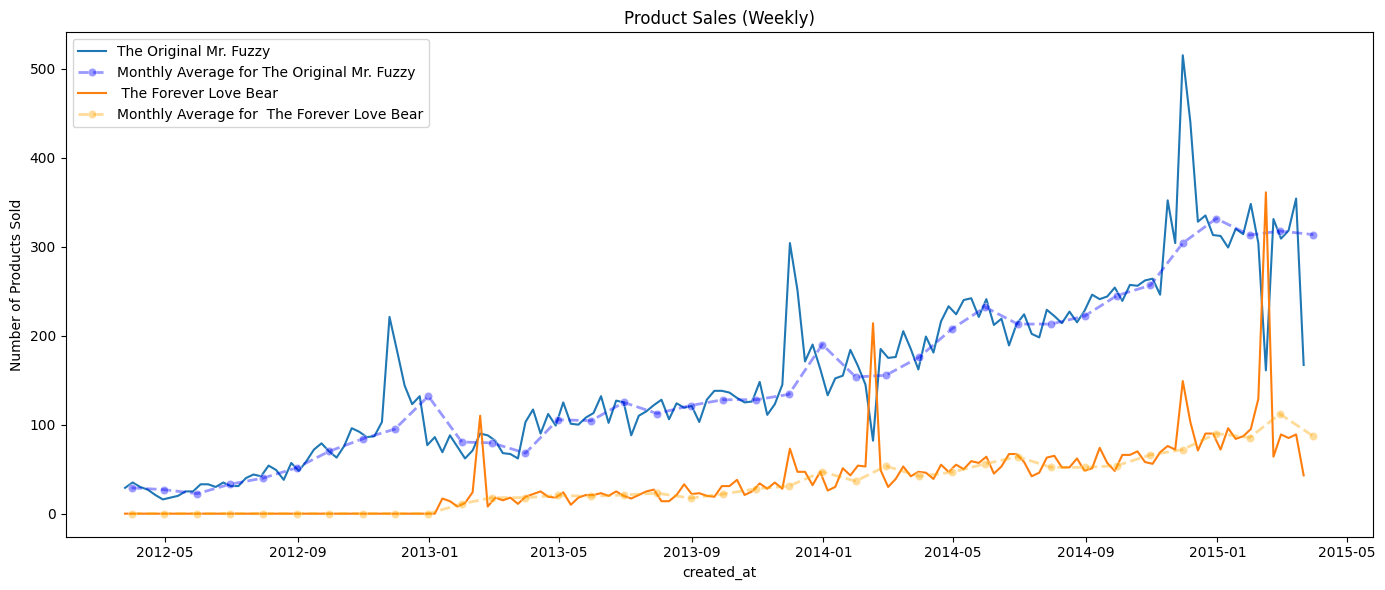

product_id    1    2  1_median  2_median
created_at                              
2013-02-17   90  110      79.5      18.0
2014-02-16   82  214     155.5      53.5
2015-02-15  161  361     317.5     112.0


In [31]:
fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))

peaks = product_sales.loc[product_sales[2] > product_sales[1], ['created_at',1,2]]
months_avg = product_sales.resample('ME', on='created_at')[[1,2]].median().reset_index()
peaks['month'] = peaks['created_at'].dt.to_period('M')
peaks = peaks.merge(
    months_avg.assign(month=months_avg['created_at'].dt.to_period('M')),
    on='month',
    how='left',
    suffixes=('', '_median')
)
peaks = peaks.drop(['month', 'created_at_median'], axis=1)
labels = ['The Original Mr. Fuzzy', ' The Forever Love Bear']

for index, label in enumerate(labels, start=1):
    sns.lineplot(
        x=product_sales['created_at'], y=product_sales[index],
        ax=ax1, label=label
    )
    sns.lineplot(
        x=months_avg['created_at'], y=months_avg[index],
        ax=ax1, label = f'Monthly Average for {label}',
        linewidth=2, linestyle='--', marker='o',
        color= 'blue' if index==1 else 'orange',
        alpha=0.4
    )

ax1.set_title('Product Sales (Weekly)')
ax1.set_ylabel('Number of Products Sold')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(peaks.set_index('created_at'))

### Seasonality and Product Competition

This line chart represents a more granular look at how `The Original Mr. Fuzzy` and `The Forever Love Bear` have an interesting seasonality dynamic compared to other products. A table highlighting the weeks where `The Forever Love Bear` exceeds `The Original Mr. Fuzzy` shows the sales for that week and their typical monthly sales for that month.

We can see that there is indeed a cannibalizing effect between these two products in February, likely tied to **Valentine's Day**. We can see that `The Original Mr. Fuzzy`'s sales drop by almost half compared to the typical monthly sales, while `The Forever Love Bear` has an increase of up to 300% in sales compared to a typical month.

We can compare the gross profit we gain in those weeks by comparing it with the typical monthly revenue:
|End-of-Week Date|Typical Gross Profit|Actual Gross Profit|
|---|---|---|
|2013-02-17| \$3084.50| \$6870 (+123%) |
|2014-02-16|\$6715|\$10526 (+70%)|
|2015-02-15|\$13868.50|\$18448 (+33%)|

The cannibalization effect is not harmful, but a beneficial cycle of seasonality of different products evident from the additional profit compared to the typical sales of the same month. There are two ways to capitalize on this:
* **Non-Seasonal Item Discounts:** By discounting other products with the purchase of `The Forever Love Bear` during Valentine's season, we could capitalize on `The Forever Love Bear`'s popularity and gain secondary purchases to drive more purchases.
* **Seasonal Item Discounts:** By discounting `The Forever Love Bear` instead of other products, we may gain more attraction and more purchases in the Valentine's season.

Visibility is also a big factor for seasonal marketing. Promotional content drives large crowds to purchase, but the website design should support the appropriate products during seasonal cycles. Recall that `The Original Mr. Fuzzy` is inferred to cannibalize other products by attracting customers away from other products. Despite being an assumption, further investigation of `The Original Mr. Fuzzy`'s traffic density should be a priority, as other products fail to scale with this product. Aside from the loss of cross-sales opportunity, the unscalable growth may also eventually lead to actual revenue loss in the coming years, evident from the widening gap between `The Original Mr. Fuzzy` and `The Forever Love Bear` on Valentine's Day. Eventually, `The Forever Love Bear` cannot cover the losses for `The Original Mr. Fuzzy`. Marketing teams and front-end developers should consider making changes to the web designs to pull customers to other products as a pilot test for future A/B testing.

---
# Summary
## Key Insights

The Maven Fuzzy Factory shows significant growth over its 3 years of operation due to a growing customer base and a reliable market for teddy bear toys. While we don't see signs of declining business health, there are many opportunities for growth and optimization the business can pursue.

1. **Weekend-Weekday Traffic Gap:**
    * Website traffic on the weekends is significantly lower compared to the weekdays, without any increase in conversion rate.
    * The gap is widening as records progress; currently, weekend traffic is almost half of the record's average daily traffic.
    * **Actionable Steps:**
      - Implementing email marketing and newsletters to promote weekend flash deals or distribute weekend-specific discounts or coupons can help increase traffic and bridge the gap between weekend and weekday sales.
      - For a more recent context (for modern e-commerce strategies), content drops and live shop streaming can reach more audiences and pull traffic further.
2. **Reliable Market:**
    * All acquisition channels are performing well and manage to continue pulling more traffic as the records progress.
    * **Actionable Steps:**
      - Expanding the acquisition channels to social media platforms can increase visibility, as social media platforms have a high traffic density daily.
      - The marketing team should develop new advertising campaigns for social media platforms to ensure a smooth launch
3. **Consolidated Products:**
    * The products in Maven Fuzzy Factory are consolidated into similar price bands and lack diversity to customer segments.
    * **Actionable Steps:**
      - Consider developing products that have seasonality appeals such as Christmas-themed, Easter-themed, or Lunar New Year-themed.
      - Consider developing everyday toys instead of consolidating to commemorative toys.
      - Consider discounts to segment products by seasonality and increase product popularity.
4. **Constrained Product Visibility Flag:**
    * Products cannot scale to `The Original Mr. Fuzzy` traffic, which may indicate an issue with other products' visibility.
    * **Actionable Steps:**
      - Investigating and updating the `/products` page to showcase all products equally.
      - Promoting other products based on seasonality and implementing discounts.
**The Next Big Step:** A recommended business tactic to help in tapping into these opportunities is to start with a referral campaign. By implementing a referral campaign, we can acquire new leads to progress with new features for the business, such as email campaigns, a membership system, and new data for customer segmentation.

## Conclusion

Maven Fuzzy Factory has demonstrated steady growth over three years with a reliable customer acquisition funnel across all channels. However, the business has clear optimization opportunities that can unlock further growth.

The most pressing issues are the widening weekend-weekday traffic gap and constrained product visibility beyond the flagship "Original Mr. Fuzzy." These suggest both a demand-side problem (lower weekend engagement) and a supply-side problem (limited product discoverability).

To capitalize on this growth trajectory, prioritize: (1) bridging the weekend traffic gap through targeted promotions, (2) investigating and improving product page visibility, and (3) testing seasonal product variants to diversify the offering. A referral program can follow once core experience improvements are validated.

The foundation is strong. These optimizations can accelerate the next phase of growth.